# Importing all required libraries

In [ ]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [ ]:
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate,
    GlobalAveragePooling2D, Conv2D, MaxPooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import Sequence
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.7.0
TensorFlow version: 2.19.0


# Kaggle setup

In [ ]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

# Model A

### Extracting dataset from kaggle

In [ ]:
!kaggle datasets download -d mehradaria/leukemia -p /content/

with zipfile.ZipFile('/content/leukemia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/A_Raw/')

Dataset URL: https://www.kaggle.com/datasets/mehradaria/leukemia
License(s): ODbL-1.0
100% 110M/110M [00:01<00:00, 106MB/s]



### Structuring folder

In [ ]:
base_path = '/content/Institution_Alpha'
os.makedirs(f'{base_path}/Healthy',   exist_ok=True)
os.makedirs(f'{base_path}/Leukemia',  exist_ok=True)

In [ ]:
for p in glob.glob('/content/A_Raw/**/Benign/*.*', recursive=True):
    shutil.copy(p, f'{base_path}/Healthy/')

for sub in ['Early', 'Pre', 'Pro']:
    for p in glob.glob(f'/content/A_Raw/**/{sub}/*.*', recursive=True):
        shutil.copy(p, f'{base_path}/Leukemia/')

print(f"Institution Alpha Ready: {len(os.listdir(base_path+'/Healthy'))} Healthy, " f"{len(os.listdir(base_path+'/Leukemia'))} Leukemia images.")


Institution Alpha Ready: 504 Healthy, 2752 Leukemia images.


### Importing Clinical Data

In [ ]:
df_alpha = pd.read_csv('/content/hospital_A_clinical.csv')

In [ ]:
def remap_path_alpha(old_path):
    filename = os.path.basename(old_path)

    for prefix in ['A_Pre_', 'A_Early_', 'A_Pro_', 'A_Benign_', 'A_H_', 'A_L_']:
        filename = filename.replace(prefix, '')

    subfolder = 'Healthy' if ('Healthy' in old_path or '_H_' in filename or 'Benign' in old_path) else 'Leukemia'

    return f'/content/Institution_Alpha/{subfolder}/{filename}'

In [ ]:
df_alpha['image_path'] = df_alpha['image_path'].apply(remap_path_alpha)

In [ ]:
df_alpha['Patient_ID'] = df_alpha['image_path'].apply(lambda x: os.path.basename(x).split('-')[-1].split('.')[0])

valid_paths = df_alpha['image_path'].apply(os.path.exists)
missing_count = (~valid_paths).sum()

if missing_count > 0:
    print(f"Warning: {missing_count} images not found on disk. Dropping missing rows...")
    df_alpha = df_alpha[valid_paths].reset_index(drop=True)
else:
    print("All CSV image paths successfully verified.")

print(f"Total valid images locked in for Alpha: {len(df_alpha)}")

All CSV image paths successfully verified.
Total valid patients locked in for training: 3256


In [ ]:
features_alpha = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                  'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

In [ ]:
unique_patients_alpha = df_alpha['Patient_ID'].unique()
print("Total unique Alpha patients:", len(unique_patients_alpha))

Total patients: 985


### Spliting data into train and test

In [ ]:
train_ids_alpha, temp_ids_alpha = train_test_split(
    unique_patients_alpha, test_size=0.3, random_state=42
)

val_ids_alpha, test_ids_alpha = train_test_split(
    temp_ids_alpha, test_size=0.5, random_state=42
)

train_df_alpha = df_alpha[df_alpha['Patient_ID'].isin(train_ids_alpha)].reset_index(drop=True)
val_df_alpha   = df_alpha[df_alpha['Patient_ID'].isin(val_ids_alpha)].reset_index(drop=True)
test_df_alpha  = df_alpha[df_alpha['Patient_ID'].isin(test_ids_alpha)].reset_index(drop=True)

# Verification checks
print("Alpha Train-Test overlap:", len(set(train_df_alpha['Patient_ID']) & set(test_df_alpha['Patient_ID'])))
print("Alpha Train-Val overlap:",  len(set(train_df_alpha['Patient_ID']) & set(val_df_alpha['Patient_ID'])))
print("Alpha Val-Test overlap:",   len(set(val_df_alpha['Patient_ID']) & set(test_df_alpha['Patient_ID'])))
print(f"Alpha Split done: {len(train_df_alpha)} Train, {len(val_df_alpha)} Val, {len(test_df_alpha)} Test rows.")

### Scaling data

In [ ]:
scaler_alpha = StandardScaler()

train_df_alpha[features_alpha] = scaler_alpha.fit_transform(train_df_alpha[features_alpha])

val_df_alpha[features_alpha]   = scaler_alpha.transform(val_df_alpha[features_alpha])
test_df_alpha[features_alpha]  = scaler_alpha.transform(test_df_alpha[features_alpha])

print(f"Alpha Scaling done: {len(train_df_alpha)} Train, {len(val_df_alpha)} Val, {len(test_df_alpha)} Test rows.")

split done: 2268 Train, 494 Val, 494 Test rows.


### Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_alpha = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df_alpha['Diagnosis'].values
)

class_weight_dict_alpha = {0: class_weights_alpha[0], 1: class_weights_alpha[1]}
print(f"Alpha Class Weights → Healthy: {class_weights_alpha[0]:.2f}, Leukemia: {class_weights_alpha[1]:.2f}")

Class Weights → Healthy: 3.25, Leukemia: 0.59


### Data Agumentation

In [ ]:
aug_alpha = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [ ]:
class LeukemiaDataGeneratorAlpha(tf.keras.utils.Sequence):

    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True, is_training=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.is_training = is_training
        self.features = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

        self.on_epoch_end()

    def __len__(self): return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle: self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        images = []

        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training: img = aug_alpha.random_transform(img)
            images.append(img)

        X_img = np.array(images)
        X_tab = batch[self.features].values.astype(np.float32)

        y = batch['Diagnosis'].values.astype(np.float32)

        return (X_img, X_tab), y

In [ ]:
alpha_train_gen = LeukemiaDataGeneratorAlpha(train_df_alpha, batch_size=32, is_training=True)
alpha_val_gen   = LeukemiaDataGeneratorAlpha(val_df_alpha,   batch_size=32, is_training=False, shuffle=False)
alpha_test_gen  = LeukemiaDataGeneratorAlpha(test_df_alpha,  batch_size=32, is_training=False, shuffle=False)

### THE DUAL-INPUT ARCHITECTURE

In [ ]:
def build_model_alpha():

    # --- IMAGE BRANCH ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(8, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH ---
    tab_input = Input(shape=(9,), name="clinical_input")
    t = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(tab_input)
    t = Dropout(0.4)(t)
    tab_features = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(t)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.4)(z)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )

    return model

In [ ]:
local_model_alpha = build_model_alpha()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        224 │ image_input[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      1,168 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        160 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905 (11.35 KB)

 Trainable params: 2,905 (11.35 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [ ]:
class LeukemiaClientAlpha(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator, class_weights):
        self.model     = model
        self.train_gen = train_generator
        self.val_gen   = val_generator
        self.class_weights = class_weights

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]

        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)

        print("\nTraining on local patient silo...")
        local_epochs = config.get("local_epochs", 2)

        self.model.fit(
            self.train_gen,
            epochs=local_epochs,
            class_weight=self.class_weights,
            verbose=1
        )

        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
local_model_alpha = build_model_alpha()

In [ ]:
callbacks_alpha = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_alpha.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [ ]:
history_alpha = local_model_alpha.fit(
    alpha_train_gen,
    validation_data=alpha_val_gen,
    epochs=15,
    callbacks=callbacks_alpha,
    class_weight=class_weight_dict_alpha,
    verbose=1
)

Epoch 1/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.4116 - loss: 0.7673
Epoch 1: val_loss improved from None to 0.68222, saving model to best_model_alpha.keras

Epoch 1: finished saving model to best_model_alpha.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 55s 615ms/step - accuracy: 0.4313 - loss: 0.7564 - val_accuracy: 0.6313 - val_loss: 0.6822
Epoch 2/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.5695 - loss: 0.6960
Epoch 2: val_loss improved from 0.68222 to 0.62675, saving model to best_model_alpha.keras

Epoch 2: finished saving model to best_model_alpha.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 480ms/step - accuracy: 0.5960 - loss: 0.6793 - val_accuracy: 0.8667 - val_loss: 0.6267
Epoch 3/15
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.7135 - loss: 0.6256
Epoch 3: val_loss improved from 0.62675 to 0.57095, saving model to best_model_alpha.keras

Epoch 3: finished saving model to best_model_alpha.keras
70/70 ━━━━━━━━━━━━━━━━━━━━ 34s 486ms/step - accuracy: 0.7299 -

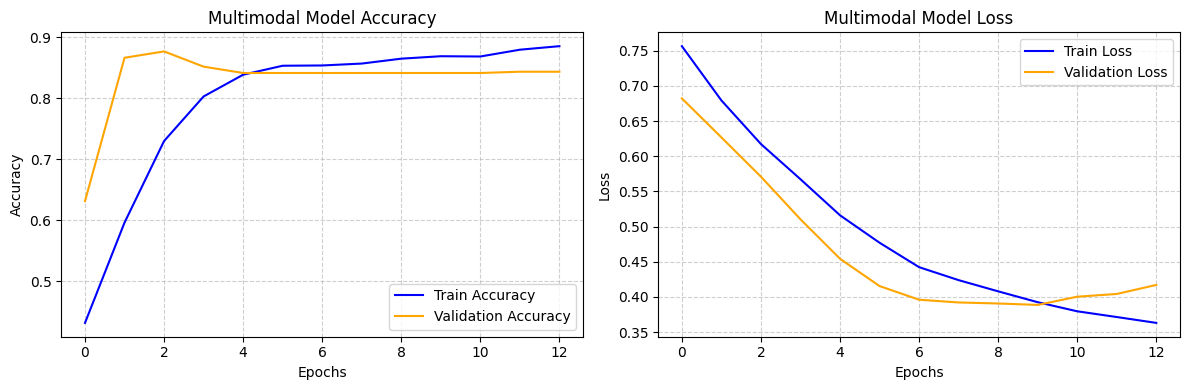

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_alpha.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_alpha.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Alpha: Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_alpha.history['loss'], label='Train Loss', color='blue')
plt.plot(history_alpha.history['val_loss'], label='Val Loss', color='orange')
plt.title('Alpha: Model Loss')
plt.legend()
plt.show()

In [ ]:
def evaluate_on_test(model, test_gen, test_df, title="Model"):
    all_probs = model.predict(test_gen, verbose=1).flatten()

    threshold = 0.3
    all_preds = (all_probs > threshold).astype(int)

    n = len(all_preds)
    all_true = test_df['Diagnosis'].values[:n].astype(int)

    acc = accuracy_score(all_true, all_preds)
    auc = roc_auc_score(all_true, all_probs)

    print(f"\n{'='*50}")
    print(f"   TEST SET RESULTS — {title}")
    print(f"{'='*50}")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   AUC-ROC  : {auc:.4f}")
    print(f"{'='*50}\n")
    print(classification_report(all_true, all_preds, target_names=["Healthy", "Leukemia"]))

    cm = confusion_matrix(all_true, all_preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Healthy", "Leukemia"], yticklabels=["Healthy", "Leukemia"], ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {title}')

    fpr, tpr, _ = roc_curve(all_true, all_probs)
    axes[1].plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f'ROC Curve — {title}')
    axes[1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

  TEST SET RESULTS — Institution Alpha
  Accuracy : 0.8354
  AUC-ROC  : 0.7607

              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00        79
    Leukemia       0.84      1.00      0.91       401

    accuracy                           0.84       480
   macro avg       0.42      0.50      0.46       480
weighted avg       0.70      0.84      0.76       480



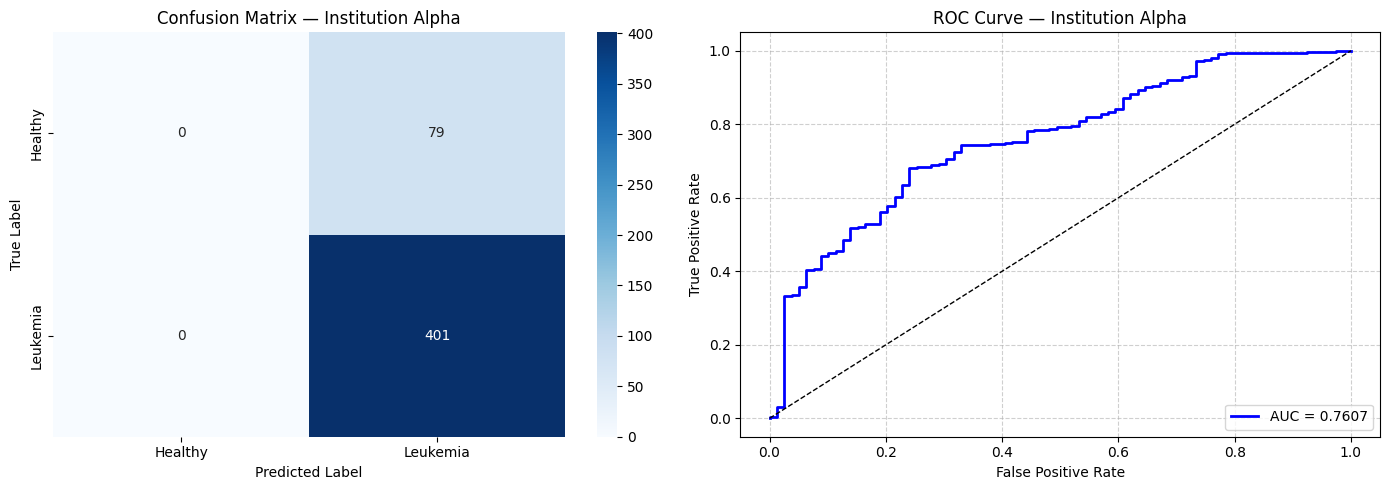

In [ ]:
evaluate_on_test(local_model_alpha, alpha_test_gen, test_df_alpha, title="Institution Alpha")

# Model B

### Extracting dataset from kaggle

In [4]:
!kaggle datasets download -d andrewmvd/leukemia-classification -p /content/

with zipfile.ZipFile('/content/leukemia-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/B_Raw/')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
leukemia-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


### Structuring folder

In [5]:
base_path = '/content/Institution_Beta'
shutil.rmtree(base_path, ignore_errors=True)
os.makedirs(f'{base_path}/Healthy', exist_ok=True)
os.makedirs(f'{base_path}/Leukemia', exist_ok=True)

In [6]:
physical_map = {}

for i, p in enumerate(glob.glob('/content/B_Raw/**/hem/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Healthy/B_H_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

for i, p in enumerate(glob.glob('/content/B_Raw/**/all/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Leukemia/B_L_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

print(f"Images Moved. Healthy: {len(os.listdir(base_path+'/Healthy'))}, Leukemia: {len(os.listdir(base_path+'/Leukemia'))}")

Images Moved. Healthy: 3389, Leukemia: 7272


### Importing Clinical Data

In [7]:
df_beta = pd.read_csv('/content/hospital_B_clinical.csv')

In [8]:
healthy_imgs_beta = sorted(glob.glob('/content/Institution_Beta/Healthy/*.bmp'))
leukemia_imgs_beta = sorted(glob.glob('/content/Institution_Beta/Leukemia/*.bmp'))

np.random.shuffle(healthy_imgs_beta)
np.random.shuffle(leukemia_imgs_beta)

df_beta['image_path'] = None

for label, image_pool in [(0, healthy_imgs_beta), (1, leukemia_imgs_beta)]:
    patients_beta = df_beta[df_beta['Diagnosis'] == label]['Patient_ID'].unique()
    idx = 0

    for p in patients_beta:
        patient_idx = df_beta[(df_beta['Patient_ID'] == p) & (df_beta['Diagnosis'] == label)].index

        for i in range(len(patient_idx)):
            if idx >= len(image_pool):
                break
            df_beta.loc[patient_idx[i], 'image_path'] = image_pool[idx]
            idx += 1

df_beta = df_beta.dropna(subset=['image_path']).reset_index(drop=True)

In [9]:
features_beta = [
    'WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
    'RBC_count', 'Hematocrit', 'Lymphocyte_percentage',
    'Neutrophil_percentage', 'Uric_acid'
]

print(f"Total valid images locked in for Beta: {len(df_beta)}")

### Spliting data into train and test

In [10]:
unique_patients_beta = df_beta['Patient_ID'].unique()

train_ids_beta, temp_ids_beta = train_test_split(
    unique_patients_beta, test_size=0.3, random_state=42
)

val_ids_beta, test_ids_beta = train_test_split(
    temp_ids_beta, test_size=0.5, random_state=42
)

train_df_beta = df_beta[df_beta['Patient_ID'].isin(train_ids_beta)].reset_index(drop=True)
val_df_beta   = df_beta[df_beta['Patient_ID'].isin(val_ids_beta)].reset_index(drop=True)
test_df_beta  = df_beta[df_beta['Patient_ID'].isin(test_ids_beta)].reset_index(drop=True)

print("Beta Train-Test overlap:", len(set(train_df_beta['Patient_ID']) & set(test_df_beta['Patient_ID'])))
print(f"Beta Split done: {len(train_df_beta)} Train, {len(val_df_beta)} Val, {len(test_df_beta)} Test rows.")

### Scaling tabular data

In [12]:
scaler_beta = StandardScaler()

train_df_beta[features_beta] = scaler_beta.fit_transform(train_df_beta[features_beta])

val_df_beta[features_beta]   = scaler_beta.transform(val_df_beta[features_beta])
test_df_beta[features_beta]  = scaler_beta.transform(test_df_beta[features_beta])

print(f"Beta Scaling done: {len(train_df_beta)} Train rows scaled.")

### Class Weight

In [28]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_beta = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df_beta['Diagnosis'].values
)

class_weight_dict_beta = {0: class_weights_beta[0], 1: class_weights_beta[1]}

print(f"Beta Class Weights → Healthy: {class_weights_beta[0]:.2f}, Leukemia: {class_weights_beta[1]:.2f}")

Class Weights → Healthy: 1.68, Leukemia: 0.71


### Data Agumentation

In [13]:
aug_beta = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

### THE MULTIMODAL DATA ENGINE

In [14]:
class LeukemiaDataGeneratorBeta(tf.keras.utils.Sequence):

    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True, is_training=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.is_training = is_training
        self.features = ['WBC_count', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

        self.on_epoch_end()

    def __len__(self): return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle: self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]
        images = []

        for p in batch['image_path']:
            img = img_to_array(load_img(p, target_size=self.target_size)) / 255.0
            if self.is_training: img = aug_beta.random_transform(img)
            images.append(img)

        X_img = np.array(images)
        X_tab = batch[self.features].values.astype(np.float32)

        y = batch['Diagnosis'].values.astype(np.float32)

        return (X_img, X_tab), y

In [15]:
beta_train_gen = LeukemiaDataGeneratorBeta(train_df_beta, is_training=True)
beta_val_gen   = LeukemiaDataGeneratorBeta(val_df_beta,   shuffle=False, is_training=False)
beta_test_gen  = LeukemiaDataGeneratorBeta(test_df_beta,  shuffle=False, is_training=False)

### THE DUAL-INPUT ARCHITECTURE

In [16]:
def build_model_beta():

    # --- IMAGE BRANCH ---
    img_input = Input(shape=(224, 224, 3), name="image_input")

    # Block 1
    x = Conv2D(8, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(img_input)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)

    # Block 2
    x = Conv2D(16, (3, 3), activation='relu', padding='same',kernel_regularizer=l2(1e-4))(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.35)(x)

    x = GlobalAveragePooling2D()(x)
    img_features = Dense(32, activation='relu',kernel_regularizer=l2(1e-4))(x)

    # --- CLINICAL BRANCH ---
    tab_input = Input(shape=(9,), name="clinical_input")
    t = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(tab_input)
    t = Dropout(0.4)(t)
    tab_features = Dense(8, activation='relu', kernel_regularizer=l2(1e-4))(t)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu', kernel_regularizer=l2(1e-4))(merged)
    z = Dropout(0.4)(z)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)

    model.compile(
        optimizer=Adam(0.0001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.Precision(name='precision')
        ]
    )

    return model

In [17]:
local_model_beta = build_model_beta()
local_model_beta.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        224 │ image_input[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 112, 112,  │          0 │ max_pooling2d[0]… │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 112, 112,  │      1,168 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 56, 56,    │          0 │ max_pooling2d_1[… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16)        │        160 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ dropout_1[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 16)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        136 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 40)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        656 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,905 (11.35 KB)

 Trainable params: 2,905 (11.35 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [18]:
class LeukemiaClientBeta(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator, class_weights):
        self.model = model
        self.train_gen = train_generator
        self.val_gen = val_generator
        self.class_weights = class_weights

    def get_parameters(self, config):
        """Differential Privacy: add tiny Gaussian noise before sharing weights."""
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]

        return noisy_weights

    def fit(self, parameters, config):
        """Receive global weights, train locally, return updated weights."""
        self.model.set_weights(parameters)
        print("\nTraining on local patient silo...")

        local_epochs = config.get("local_epochs", 2)
        self.model.fit(
            self.train_gen,
            epochs=local_epochs,
            class_weight=self.class_weights,
            verbose=1
        )

        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """Evaluate global model on local validation set."""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [ ]:
local_model_beta = build_model_beta()

In [19]:
callbacks_beta = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_beta.keras', monitor='val_loss', save_best_only=True, verbose=1)
]

In [20]:
history_beta = local_model_beta.fit(
    beta_train_gen,
    validation_data=beta_val_gen,
    epochs=15,
    callbacks=callbacks_beta,
    class_weight=class_weight_dict_beta,
    verbose=1
)

Epoch 1/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.5567 - loss: 0.7235
Epoch 1: val_loss improved from None to 0.66846, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 137s 541ms/step - accuracy: 0.6009 - loss: 0.7090 - val_accuracy: 0.7690 - val_loss: 0.6685
Epoch 2/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6804 - loss: 0.6767
Epoch 2: val_loss improved from 0.66846 to 0.62612, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 121s 511ms/step - accuracy: 0.7003 - loss: 0.6657 - val_accuracy: 0.8021 - val_loss: 0.6261
Epoch 3/15
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.7462 - loss: 0.6312
Epoch 3: val_loss improved from 0.62612 to 0.55637, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 114s 481ms/step - accuracy: 0.7613 - loss: 0.6136 - val_a

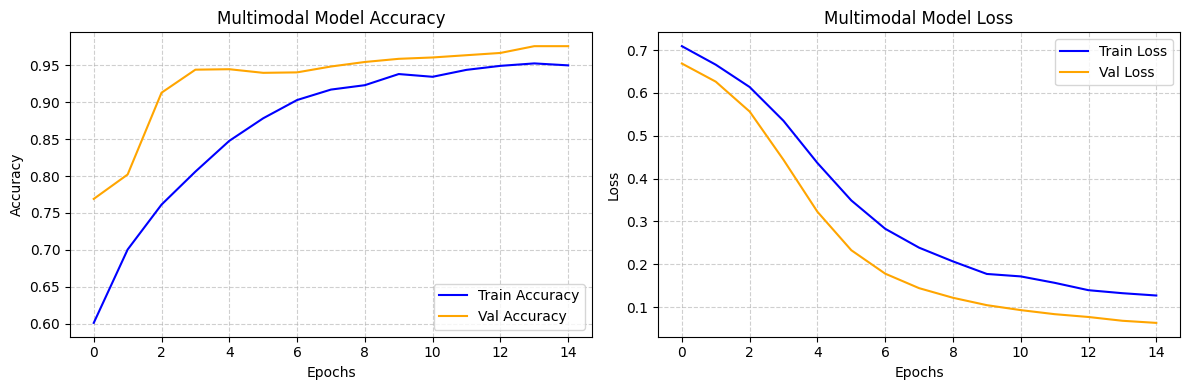

In [21]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_beta.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_beta.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Beta: Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_beta.history['loss'], label='Train Loss', color='blue')
plt.plot(history_beta.history['val_loss'], label='Val Loss', color='orange')
plt.title('Beta: Model Loss')
plt.legend()
plt.show()

In [26]:
def evaluate_on_test(model, test_gen, test_df, title="Model"):
    all_probs = model.predict(test_gen, verbose=1).flatten()

    threshold = 0.3
    all_preds = (all_probs > threshold).astype(int)

    n = len(all_preds)
    all_true = test_df['Diagnosis'].values[:n].astype(int)

    acc = accuracy_score(all_true, all_preds)
    auc = roc_auc_score(all_true, all_probs)

    print(f"\n{'='*50}")
    print(f"   TEST SET RESULTS — {title}")
    print(f"{'='*50}")
    print(f"   Accuracy : {acc:.4f}")
    print(f"   AUC-ROC  : {auc:.4f}")
    print(f"{'='*50}\n")
    print(classification_report(all_true, all_preds, target_names=["Healthy", "Leukemia"]))

    cm = confusion_matrix(all_true, all_preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Healthy", "Leukemia"], yticklabels=["Healthy", "Leukemia"], ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {title}')

    fpr, tpr, _ = roc_curve(all_true, all_probs)
    axes[1].plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}', linewidth=2)
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title(f'ROC Curve — {title}')
    axes[1].legend(loc='lower right')
    plt.tight_layout()
    plt.show()

43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 147ms/step

  TEST SET RESULTS — Institution Beta
  Accuracy : 0.9927
  AUC-ROC  : 0.9999

              precision    recall  f1-score   support

     Healthy       1.00      0.99      0.99       750
    Leukemia       0.99      1.00      0.99       626

    accuracy                           0.99      1376
   macro avg       0.99      0.99      0.99      1376
weighted avg       0.99      0.99      0.99      1376



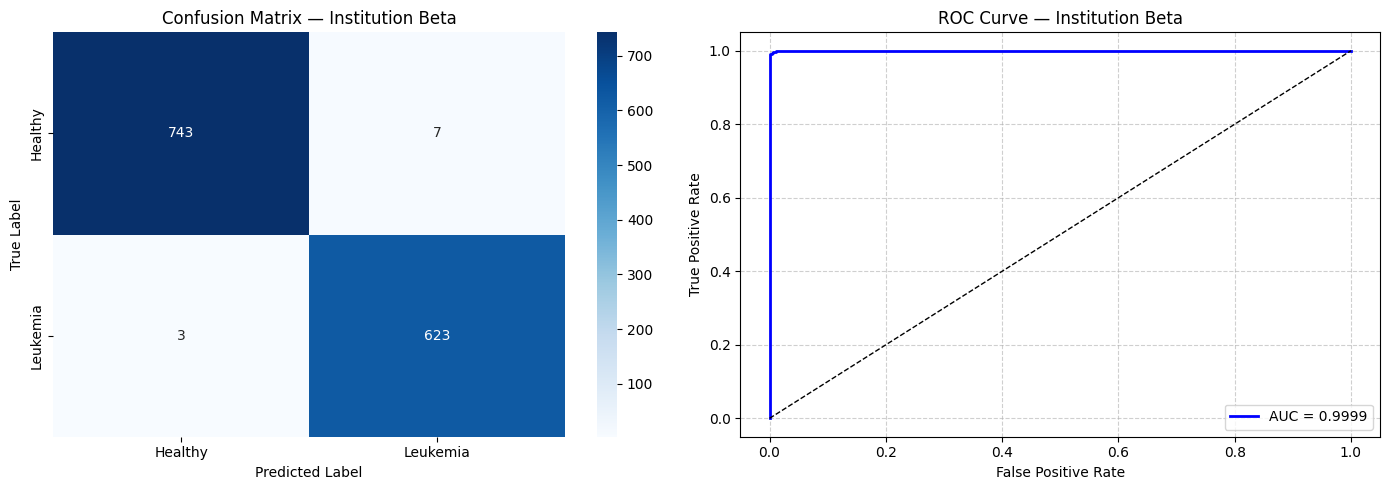

In [27]:
evaluate_on_test(local_model_beta, beta_test_gen, test_df_beta, title="Institution Beta")

# Federated Learning

In [ ]:
def client_fn(cid: str):

    if cid == "0":
        model = build_model_alpha()

        return LeukemiaClientAlpha(
            model,
            alpha_train_gen,
            alpha_val_gen,
            class_weight_dict_alpha
        ).to_client()
    else:
        model = build_model_beta()

        return LeukemiaClientBeta(
            model,
            beta_train_gen,
            beta_val_gen,
            class_weight_dict_beta
        ).to_client()

def fit_config(rnd):
    return {"local_epochs": 2 if rnd <= 3 else 1}

### FedAvg

In [ ]:
class SaveModelStrategy(fl.server.strategy.FedAvg):
    def aggregate_fit(self, server_round, results, failures):
        aggregated_parameters, aggregated_metrics = super().aggregate_fit(server_round, results, failures)

        if aggregated_parameters is not None:
            print(f"\nSaving Global Model for Round {server_round}...")
            aggregated_ndarrays = fl.common.parameters_to_ndarrays(aggregated_parameters)

            temp_model = build_model_alpha()
            temp_model.set_weights(aggregated_ndarrays)

            temp_model.save(f"global_model_round_{server_round}.keras")

        return aggregated_parameters, aggregated_metrics

In [ ]:
def weighted_average(metrics):
    accuracies = [num_examples * m["accuracy"] for num_examples, m in metrics]
    examples = [num_examples for num_examples, _ in metrics]
    return {"accuracy": sum(accuracies) / sum(examples)}

In [ ]:
strategy = SaveModelStrategy(
    fraction_fit=1.0,
    fraction_evaluate=1.0,
    min_fit_clients=2,
    min_evaluate_clients=2,
    min_available_clients=2,
    on_fit_config_fn=fit_config,
    evaluate_metrics_aggregation_fn=weighted_average,
)

### Starting Server

In [ ]:
fl_history = fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=2,
    config=fl.server.ServerConfig(num_rounds=5),
    strategy=strategy,
    client_resources={"num_cpus": 2, "num_gpus": 0},
)

### Global Model plots

In [ ]:
rounds = [r for r, _ in fl_history.metrics_distributed['accuracy']]
acc_vals = [v for _, v in fl_history.metrics_distributed['accuracy']]
loss_vals = [v for _, v in fl_history.losses_distributed]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rounds, acc_vals, marker='o', color='teal', linewidth=2)
axes[0].set_title('Federated Accuracy (Distributed)')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].plot(rounds, loss_vals, marker='o', color='crimson', linewidth=2)
axes[1].set_title('Federated Loss (Distributed)')
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Loss')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Evaluation of Global Model

In [ ]:
def evaluate_on_test(model, test_gen, test_df, title="Model"):
    all_probs = model.predict(test_gen, verbose=1).flatten()
    threshold = 0.3
    all_preds = (all_probs > threshold).astype(int)
    n         = len(all_probs)
    all_true  = test_df['Diagnosis'].values[:n].astype(int)

    acc = accuracy_score(all_true, all_preds)
    auc = roc_auc_score(all_true, all_probs)

    print(f"\n{'='*50}")
    print(f"  TEST SET RESULTS — {title}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  AUC-ROC  : {auc:.4f}")
    print(f"{'='*50}\n")
    print(classification_report(all_true, all_preds, target_names=["Healthy", "Leukemia"]))

    cm = confusion_matrix(all_true, all_preds)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Healthy","Leukemia"],
                yticklabels=["Healthy","Leukemia"], ax=axes[0])
    axes[0].set_title(f'Confusion Matrix — {title}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr, tpr, _ = roc_curve(all_true, all_probs)
    axes[1].plot(fpr, tpr, color='blue', label=f'AUC = {auc:.4f}', linewidth=2)
    axes[1].plot([0,1],[0,1],'k--')
    axes[1].set_title(f'ROC Curve — {title}')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [ ]:
### Final Global Model Evaluation

print("\n" + "="*50)
print(" LOADING AND EVALUATING FINAL GLOBAL MODEL")
print("="*50)


final_global_model = tf.keras.models.load_model("global_model_round_5.keras")

evaluate_on_test(
    final_global_model,
    alpha_test_gen,
    test_df_alpha,
    title="Global Model (Round 5) — Tested on Alpha"
)

evaluate_on_test(
    final_global_model,
    beta_test_gen,
    test_df_beta,
    title="Global Model (Round 5) — Tested on Beta"
)